## Environment setup

In [ ]:
from datetime import datetime 
import importlib
from functools import partial

import tensorflow as tf
from tensorflow.data import Dataset, TFRecordDataset
import tensorflow_datasets as tfds

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
from matplotlib import colors
import seaborn as sns

# Notebooks run from VSCode use home directory as a base path
# while notebooks ran from JupyterLab use the current directory as a base path
import sys, os

user = os.getenv("USER")
if user == "jovyan":
    sys.path.append("/home/jovyan/ELITPC/TPCReco/PythonAnalysis/python/")
else:
    sys.path.append("/home/akalinow/scratch/ELITPC/TPCReco/PythonAnalysis/python/")
    os.chdir('/home/akalinow/scratch/ELITPC/TPCReco/PythonAnalysis/ipynb/')


os.mkdir("fig_png", exist_ok=True)

#Increase plots font size
params = {'legend.fontsize': 'xx-large',
          'figure.figsize': (10, 7),
         'axes.labelsize': 'xx-large',
         'axes.titlesize':'xx-large',
         'xtick.labelsize':'xx-large',
         'ytick.labelsize':'xx-large'}
plt.rcParams.update(params)

### Load the dataset and convert to pandas DataFrame

In [ ]:
fileName = 'SimEvent_Track3D_TwoProng_gun_MC_2025-12-18T11-06.root'

In [ ]:
import io_functions as io
importlib.reload(io)

dataPath = '/home/akalinow/scratch/ELITPC/TPCReco/build_with_TF/resources/'
rootFiles = [dataPath+fileName+':TPCData']

# Convert ROOT files to TF format and save to output directory
simOutputDir = 'SimEvent_Track3D_TwoProng_gun_MC_test'
io.convertROOT(rootFiles, simOutputDir, fields= io.simEventFields)

# uproot always takes the first branch with given name, unless 
# explicit branch is given as input path. Filtering by branches in
# iterate does not work. We have to give full path to the branch: TPCData/RecoEvent
rootFiles = [aFile+'/RecoEvent' for aFile in rootFiles]

# Convert ROOT files to TF format and save to output directory
recoOutputDir = 'RecoEvent_Track3D_TwoProng_gun_MC_test'
io.convertROOT(rootFiles, recoOutputDir, fields=io.recoEventFields)

# merge SimEvent and RecoEvent data

simOutputDir = 'SimEvent_Track3D_TwoProng_gun_MC_test'
recoOutputDir = 'RecoEvent_Track3D_TwoProng_gun_MC_test'

simDataset = tf.data.Dataset.load(simOutputDir, compression="GZIP")
recoDataset = tf.data.Dataset.load(recoOutputDir, compression="GZIP")

mergedDataset = tf.data.Dataset.zip((simDataset, recoDataset))
mergedDataset = mergedDataset.map(
    lambda sim, reco: {
        'sim': sim,
        'reco': reco
    }
)

# filter merged dataset
# calculate sim alpha length and select events with length > 30 mm
minAlphaLength = 30.0
mergedDataset = mergedDataset.filter(
    lambda x: tf.reduce_all(
        tf.greater(
            tf.sqrt(
                tf.math.reduce_sum(tf.square(x['sim'][1][:,0] - x['sim'][1][:,1]), axis=-1)
            ), minAlphaLength
        )
    )
)

# calculate sim alpha length and select events with length < 100 mm
maxAlphaLength = 100.0
mergedDataset = mergedDataset.filter(
    lambda x: tf.reduce_all(
        tf.less(
            tf.sqrt(
                tf.math.reduce_sum(tf.square(x['sim'][1][:,0] - x['sim'][1][:,1]), axis=-1)
            ), maxAlphaLength
        )
    )
)

# save merged dataset
outputDir = 'MergedEvent_Track3D_TwoProng_gun_MC_test'
mergedDataset.save(outputDir, compression="GZIP")

In [7]:
!pwd

/scratch_hdd/akalinow/ELITPC/PythonAnalysis


In [10]:
%%time 

import utility_functions as utils
importlib.reload(utils)

#dataset = tf.data.Dataset.load('MergedEvent_Track3D_TwoProng_gun_MC_test', compression="GZIP")
dataset = tf.data.Dataset.load('MergedEvent_Track3D_TwoProng_gun_MC_100k_fiducial', compression="GZIP").take(10000)

data = dataset.map(lambda x: tf.reshape(x["sim"][1], (1,-1))).unbatch().as_numpy_iterator()
df_sim = pd.DataFrame(data, columns=utils.columnsXYZ)

data = dataset.map(lambda x: tf.reshape(x["reco"][1], (1,-1))).unbatch().as_numpy_iterator()
df_reco = pd.DataFrame(data, columns=utils.columnsXYZ)

df_XYZ = df_sim.merge(df_reco, left_index=True, right_index=True, suffixes=("_sim", "_reco"), how="outer");

Cause: could not parse the source code of <function <lambda> at 0x7f43ea6107c0>: no matching AST found among candidates:

To silence this warning, decorate the function with @tf.autograph.experimental.do_not_convert
Cause: could not parse the source code of <function <lambda> at 0x7f43ea6107c0>: no matching AST found among candidates:

To silence this warning, decorate the function with @tf.autograph.experimental.do_not_convert


2026-03-31 13:32:03.324294: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:998] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
2026-03-31 13:32:03.326669: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:998] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
2026-03-31 13:32:03.336022: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:998] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-

Cause: could not parse the source code of <function <lambda> at 0x7f440a7efa60>: no matching AST found among candidates:

To silence this warning, decorate the function with @tf.autograph.experimental.do_not_convert
Cause: could not parse the source code of <function <lambda> at 0x7f440a7efa60>: no matching AST found among candidates:

To silence this warning, decorate the function with @tf.autograph.experimental.do_not_convert


2026-03-31 13:32:35.458283: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


CPU times: user 1min 9s, sys: 864 ms, total: 1min 10s
Wall time: 1min 4s


2026-03-31 13:33:07.207810: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


### Resolution plots in XYZ

FileNotFoundError: [Errno 2] No such file or directory: 'fig_png/Vtx_resolution.png'

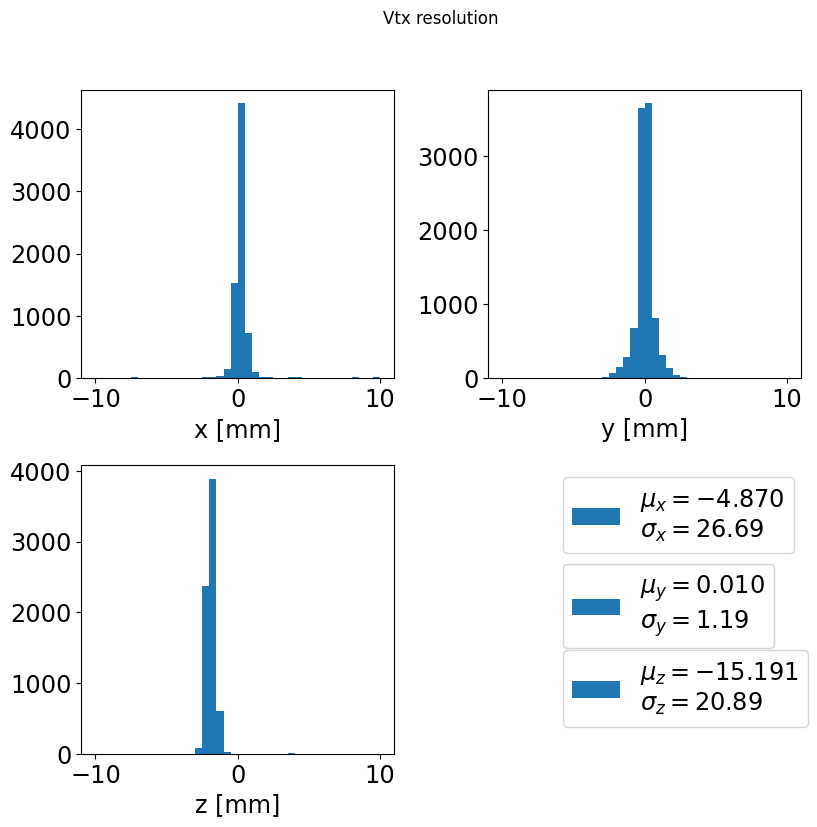

In [11]:
import plotting_functions as plf
importlib.reload(plf)

#plf.controlPlots(df)
plf.plotEndPointRes(df=df_XYZ, edge="Vtx", coordinates=["x", "y", "z"])
plf.plotEndPointRes(df=df_XYZ, edge="Alpha", coordinates=["x", "y", "z"])
plf.plotEndPointRes(df=df_XYZ, edge="Carbon", coordinates=["x", "y", "z"])

plf.plotLengthPull(df_XYZ, partName="Alpha")
plf.plotLengthPull(df_XYZ, partName="Carbon")
plf.plotLengthPullEvolution(df_XYZ)
plf.plotOpeningAngleCos(df_XYZ)

### Efficiency maps as a function of detector azumuthal and polar angles

In [81]:
import plotting_functions as plf
importlib.reload(plf)

numeratorSelection = (df_XYZ["pullAlpha"]/df_XYZ["dAlpha_sim"] < 0.05)
denominatorSelection = (np.abs(df_XYZ["xAlpha_sim"]) < 140) & (np.abs(df_XYZ["yAlpha_sim"]) < 90) & (np.abs(df_XYZ["zAlpha_sim"]) < 60)

plf.plotEffMaps(df_XYZ, numeratorSelection, denominatorSelection)

### Resolution plots in UVWT

In [10]:
import utility_functions as utils
importlib.reload(utils)

batchSize = 32
dataset = tf.data.Dataset.load('MergedEvent_Track3D_TwoProng_gun_MC_test', compression="GZIP")

data = dataset.map(lambda x: tf.reshape(x["sim"][1], (1,-1)))
data = data.map(lambda x: tf.reshape(x, (-1,3,3)))
data = data.map(lambda x: utils.XYZtoUVWT_event(x))
data = data.map(lambda x: tf.reshape(x, (-1,12))).unbatch().as_numpy_iterator()

df_sim = pd.DataFrame(data, columns=utils.columnsUVWT)

data = dataset.map(lambda x: tf.reshape(x["reco"][1], (1,-1)))
data = data.map(lambda x: tf.reshape(x, (-1,3,3)))
data = data.map(lambda x: utils.XYZtoUVWT_event(x))
data = data.map(lambda x: tf.reshape(x, (-1,12))).unbatch().as_numpy_iterator()
df_reco = pd.DataFrame(data, columns=utils.columnsUVWT)

df_UVWT = df_sim.merge(df_reco, left_index=True, right_index=True, suffixes=("_sim", "_reco"), how="outer");

2026-03-31 07:41:10.127813: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


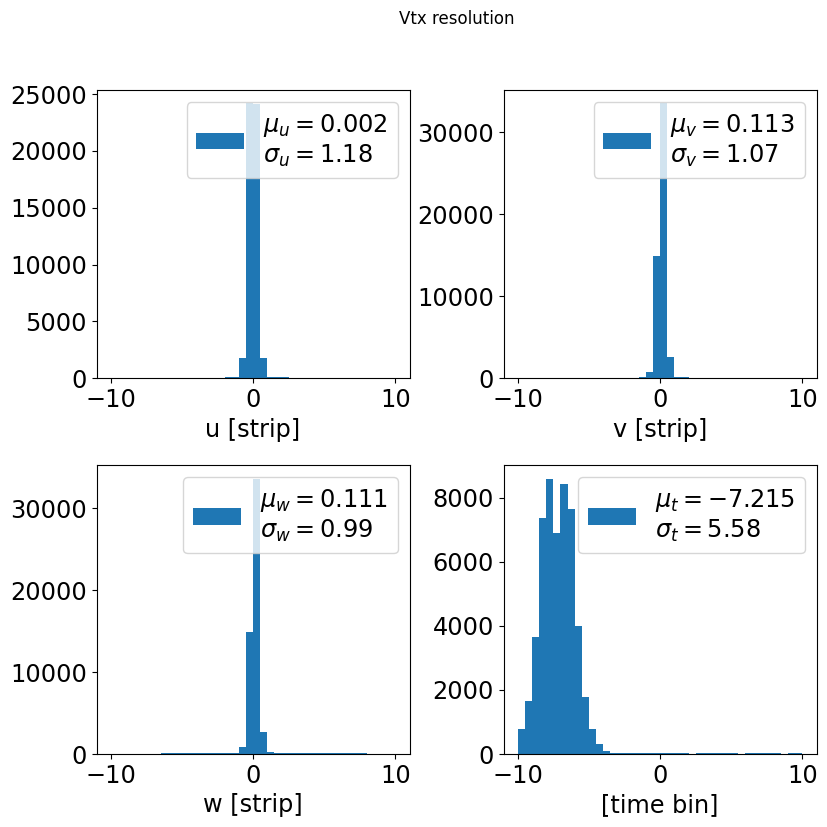

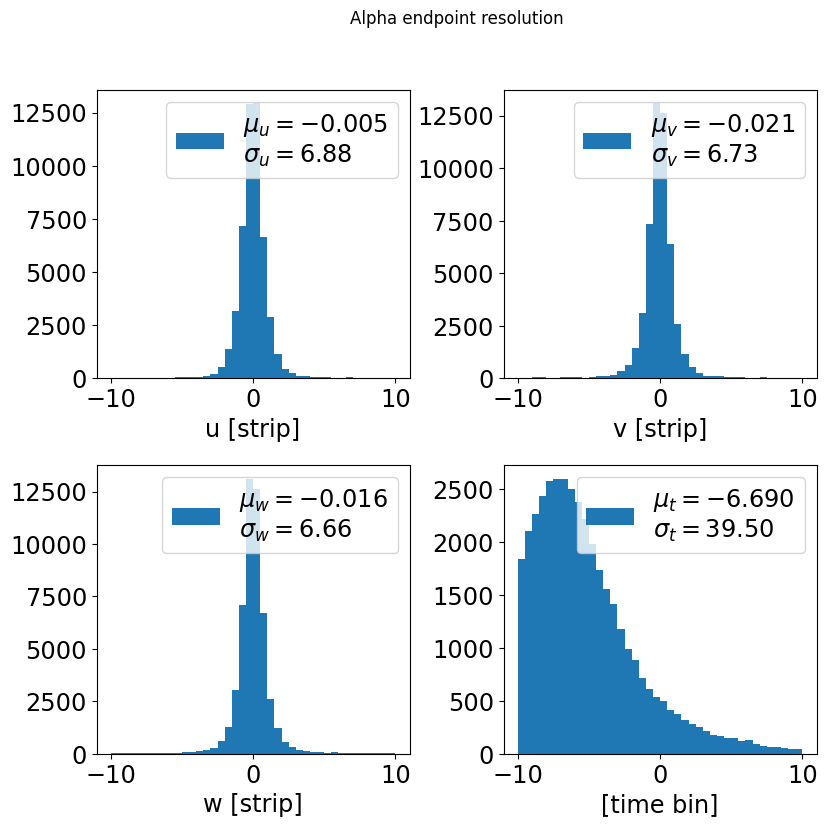

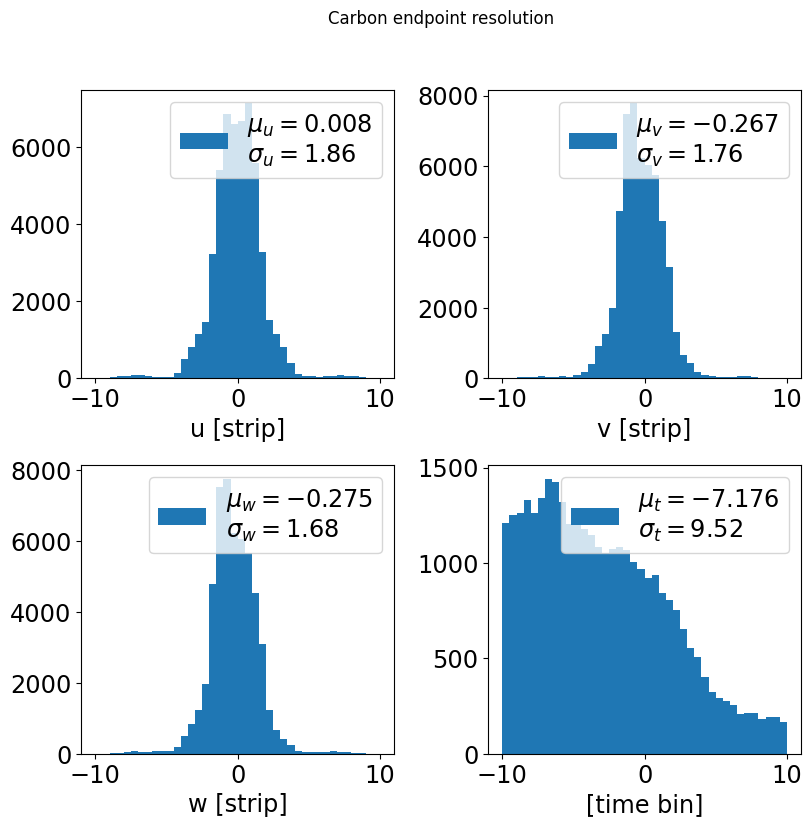

In [11]:
import plotting_functions as plf
importlib.reload(plf)

plf.plotEndPointRes(df=df_UVWT, edge="Vtx", coordinates=["u", "v", "w", "t"])
plf.plotEndPointRes(df=df_UVWT, edge="Alpha", coordinates=["u", "v", "w", "t"])
plf.plotEndPointRes(df=df_UVWT, edge="Carbon", coordinates=["u", "v", "w", "t"])